<h1>Emmanuel M. Aviles | Dengue analysis</h1>

<h2> 1. Imports </h2>


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

<h2>2. Data </h2>

In [2]:
df = pd.read_csv('dengue.csv')
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


<h2>3.Data Information</h2>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


<h2>4. Basic Descriptive Statistics</h2>

In [4]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


<h2>5. Checking Null Values</h2>

In [5]:
df.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<h2>6. Checking Data Columns</h2>

In [6]:
df.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<h2>7. Adding usable columns</h2>

In [7]:
df['Case_Fatality_Rate'] = (df['Dengue_Deaths'] / df['Dengue_Cases']) * 100

In [8]:
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths,Case_Fatality_Rate
0,January,2016,Region I,705,1,0.141844
1,February,2016,Region I,374,0,0.000000
2,March,2016,Region I,276,0,0.000000
3,April,2016,Region I,240,2,0.833333
4,May,2016,Region I,243,1,0.411523
...,...,...,...,...,...,...
1015,August,2020,BARMM,91,0,0.000000
1016,September,2020,BARMM,16,8,50.000000
1017,October,2020,BARMM,13,9,69.230769
1018,November,2020,BARMM,15,1,6.666667


In [9]:
Regional_Death = df.groupby(["Region"])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()

In [10]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases
0,BARMM,332,11537
1,CAR,1008,30582
2,NCR,4008,115966
3,Region I,157,59066
4,Region II,193,45141
5,Region III,482,131064
6,Region IV-A,652,163029
7,Region IV-B,130,30849
8,Region IX,532,47781
9,Region V,185,22167


In [11]:
Regional_Death["Mortality_Rate"] = np.round((Regional_Death["Dengue_Deaths"] / Regional_Death["Dengue_Cases"]) * 100,2)

In [12]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases,Mortality_Rate
0,BARMM,332,11537,2.88
1,CAR,1008,30582,3.30
2,NCR,4008,115966,3.46
3,Region I,157,59066,0.27
4,Region II,193,45141,0.43
5,Region III,482,131064,0.37
6,Region IV-A,652,163029,0.40
7,Region IV-B,130,30849,0.42
8,Region IX,532,47781,1.11
9,Region V,185,22167,0.83


In [13]:
df.isnull().sum()

Month                 0
Year                  0
Region                0
Dengue_Cases          0
Dengue_Deaths         0
Case_Fatality_Rate    0
dtype: int64

<h1>VISUALIZATIONS AND 10 INSIGHTS</h1>

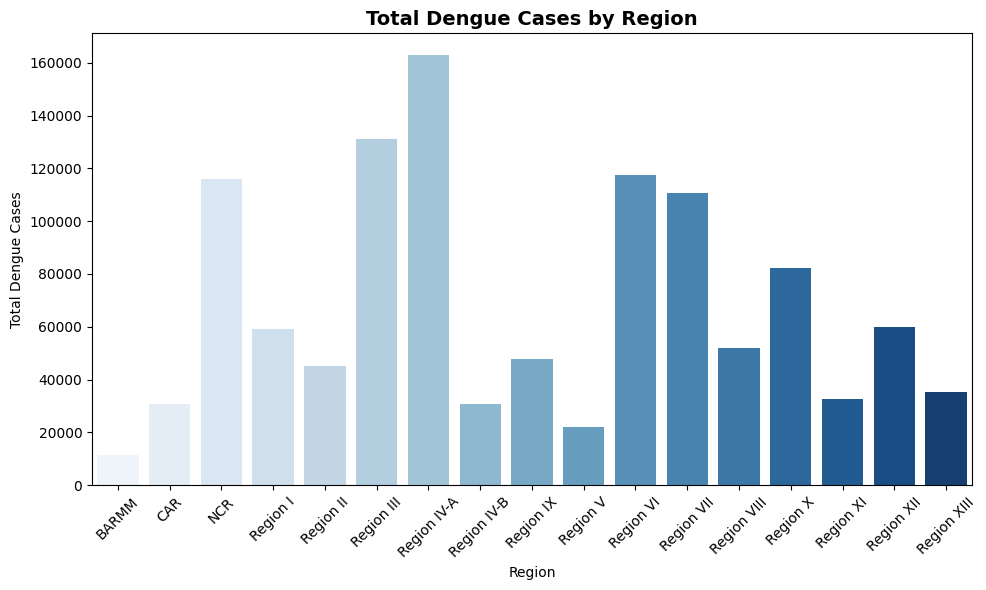

In [14]:
cases_region = df.groupby('Region')['Dengue_Cases'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=cases_region, x='Region', y='Dengue_Cases', palette='Blues')
plt.title('Total Dengue Cases by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Dengue Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h2>Insight 1:According to the Bar Graph Region 4-A has the highest case of dengue in the whole country.
</h2>
<h2>
Insight 2: Maybe because the Region 4-A has the highest population in the northern part of the country that combination of CALABARZON where is the weather was humid, which was very favorable to mosquitoes.</h2>

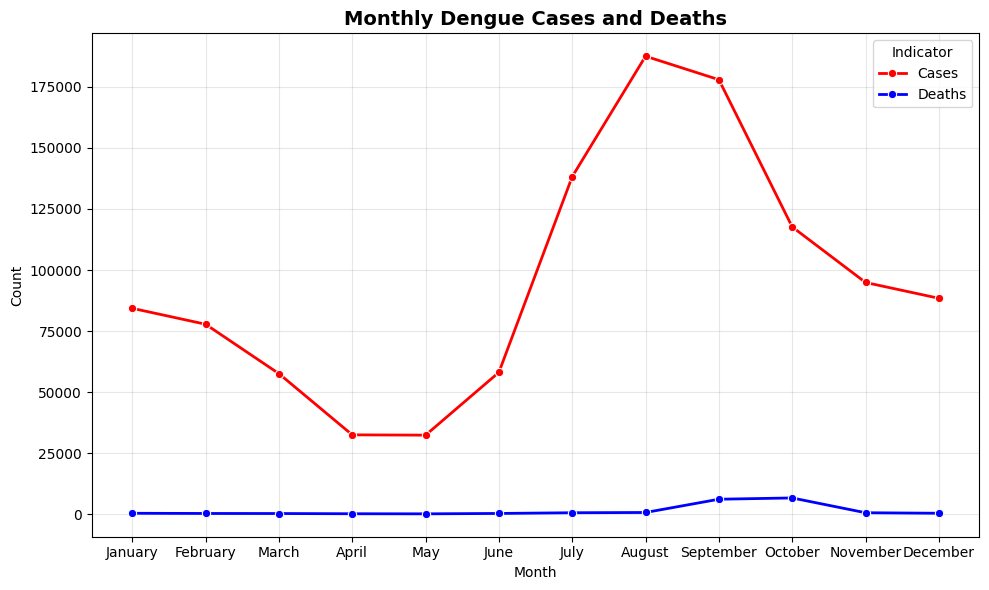

In [15]:
monthly = df.groupby('Month')[['Dengue_Cases', 'Dengue_Deaths']].sum().reset_index()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly, x='Month', y='Dengue_Cases', marker='o', label='Cases', color='red', linewidth=2)
sns.lineplot(data=monthly, x='Month', y='Dengue_Deaths', marker='o', label='Deaths', color='blue', linewidth=2)

plt.title('Monthly Dengue Cases and Deaths', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Indicator')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Insight 1: Base on this graph cases in during summer plummeted but it spike back when its raining season it reaches it peak count for the whole year like from june where el nina usually starts till december. But here in this data it reaches the peak on august which is above 180,000 through 2016 to 2020
</h2>
<h2>
Insight 2: But despite the high cases, deaths didn't skyrocketed like the cases. </h2>

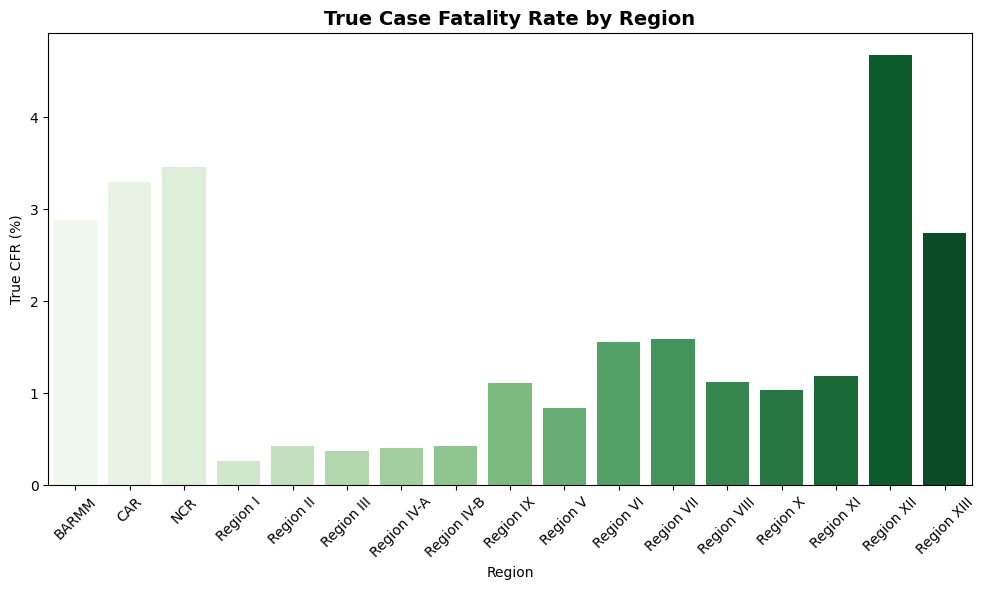

In [16]:
region_true_cfr = df.groupby('Region').sum(numeric_only=True).reset_index()
region_true_cfr['True_CFR'] = (region_true_cfr['Dengue_Deaths'] / region_true_cfr['Dengue_Cases']) * 100

plt.figure(figsize=(10,6))
sns.barplot(data=region_true_cfr, x='Region', y='True_CFR', palette='Greens')
plt.title('True Case Fatality Rate by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('True CFR (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h2>Insight 1: Base on the graph here even the highest cases was in the region 4-A. Region XII has the highest fatality it means they have the most death cases, Region XII was a region in Mindanao and it is a rural area so we can say that most people just don't want to get treated because they might think its only a fever.
</h2>
<h2>
Insight 2: But in the Region 4-A despite the high cases they manage to minimize the fatality it means that region is capable of keeping the dengue in check.</h2>

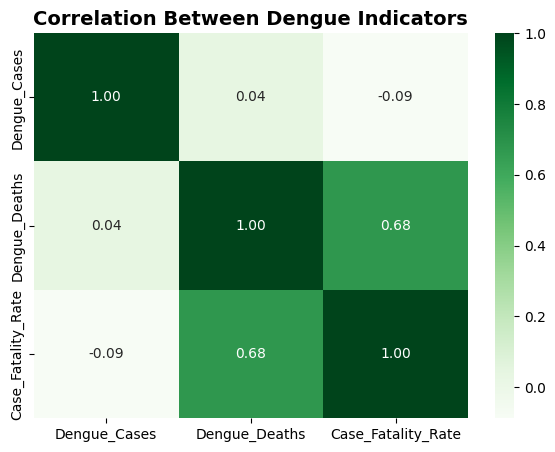

In [17]:
num_cols = ['Dengue_Cases', 'Dengue_Deaths', 'Case_Fatality_Rate']

# Compute correlation matrix
corr = df[num_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='Greens', fmt=".2f")
plt.title('Correlation Between Dengue Indicators', fontsize=14, fontweight='bold')
plt.show()

<h2>Insight 1: The region with the highest number of cases experienced the most widespread transmission, possibly due to higher population density or poor sanitation.
</h2>
<h2>
Insight 2: Regions with very low case counts may have effective mosquito control programs or lower population exposure.</h2>

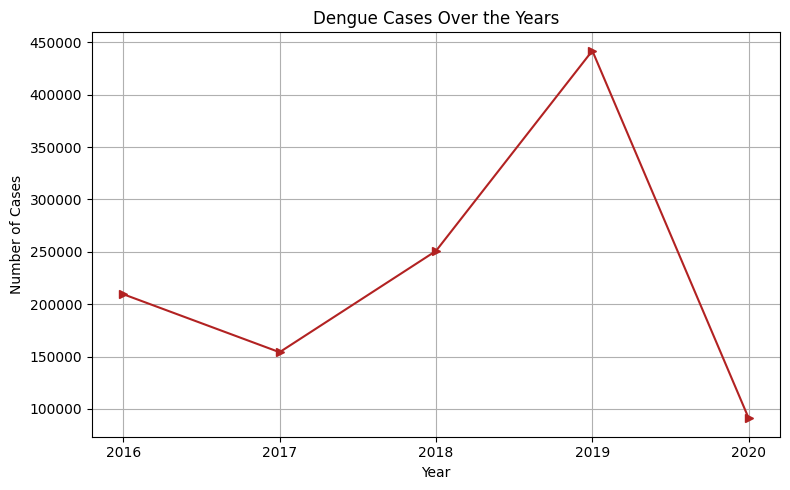

In [20]:
yearly_cases = df.groupby('Year')['Dengue_Cases'].sum().reset_index()
yearly_cases['Year'] = yearly_cases['Year'].astype(int)

plt.figure(figsize=(8, 5))
plt.plot(yearly_cases['Year'], yearly_cases['Dengue_Cases'], marker='>', color='firebrick')
plt.title('Dengue Cases Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.xticks(yearly_cases['Year']) 
plt.grid(True)
plt.tight_layout()
plt.show()

<h2>Insight 1: The trend shows a sharp increase in dengue cases from 2017 to 2019, peaking significantly in 2019, which may indicate a major outbreak or intensified transmission during that year.
</h2>
<h2>
Insight 2: But after the outbreak it dropped drastically because this time covid-19 virus was in outbreak and peoples are quarantined maybe thats one of the reason it dropped.</h2>